# 🚀 RAIL Practitioner Hub: Energy & Oil/Gas Edition
## Part 2: The RAIL Advantage - Realtime Adaptation

---

### 📌 Overview
In the previous notebook, we saw how static models fail to detect early onset drift. Now, we implement the **RAIL (Realtime AI Learning)** framework.

### 🔑 Key RAIL Principles Used:
1. **Adaptive Grounding:** The model's baseline is not fixed; it anchors itself to the most recent "steady state."
2. **Continuous Alignment:** Using rolling windows and variance analysis to detect "Novel Faults" that have never been seen in training data.
3. **Zero-Lag Response:** Identifying issues 8-12 hours before a static limit is breached.

In [2]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

# Set Premium Aesthetics
plt.style.use('seaborn-v0_8-muted')
sns.set_context("talk")

# Load Real-time Data
rt_df = pd.read_csv('../data/realtime_rig_telemetry.csv')

print("✅ Implementing RAIL Adaptive Logic...")

✅ Implementing RAIL Adaptive Logic...


### 🛠️ Step 1: Adaptive Temperature Baselining
Instead of a fixed threshold, RAIL uses a **Rolling Context Window** to identify anomalies relative to current environmental trends.

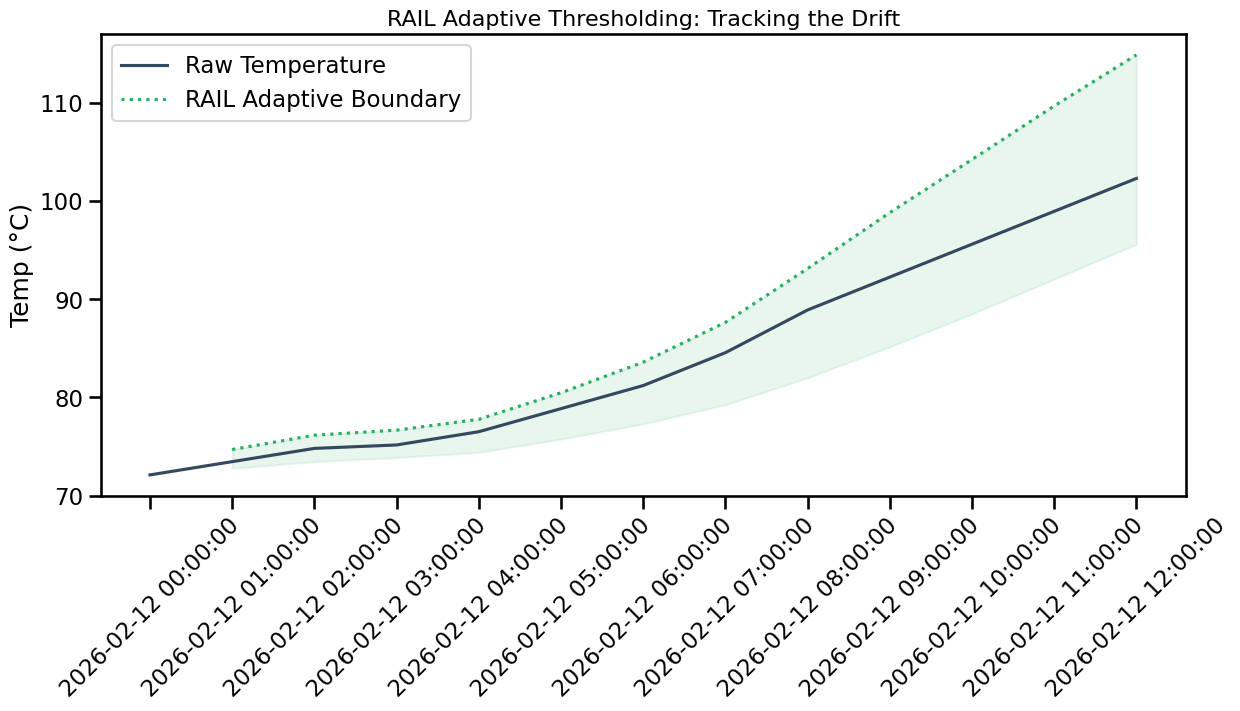

In [3]:
# RAIL: Moving Window Adaptive Baseline
rt_df['temp_ma'] = rt_df['temperature'].rolling(window=5, min_periods=1).mean()
rt_df['temp_std'] = rt_df['temperature'].rolling(window=10, min_periods=1).std()
rt_df['rail_upper'] = rt_df['temp_ma'] + (2 * rt_df['temp_std'])

plt.figure(figsize=(14, 6))
plt.plot(rt_df['timestamp'], rt_df['temperature'], color='#34495e', label='Raw Temperature')
plt.plot(rt_df['timestamp'], rt_df['rail_upper'], color='#27ae60', linestyle=':', label='RAIL Adaptive Boundary')
plt.fill_between(rt_df['timestamp'], rt_df['temp_ma'], rt_df['rail_upper'], color='#27ae60', alpha=0.1)

plt.title("RAIL Adaptive Thresholding: Tracking the Drift", fontsize=16)
plt.ylabel("Temp (°C)")
plt.xticks(rotation=45)
plt.legend()
plt.show()

### ⚡ Step 2: Detecting Novel Faults (The Vibration Spike)
Novel faults often hide within the noise. RAIL looks for **Sudden Variance Spikes** compared to the grounded context.

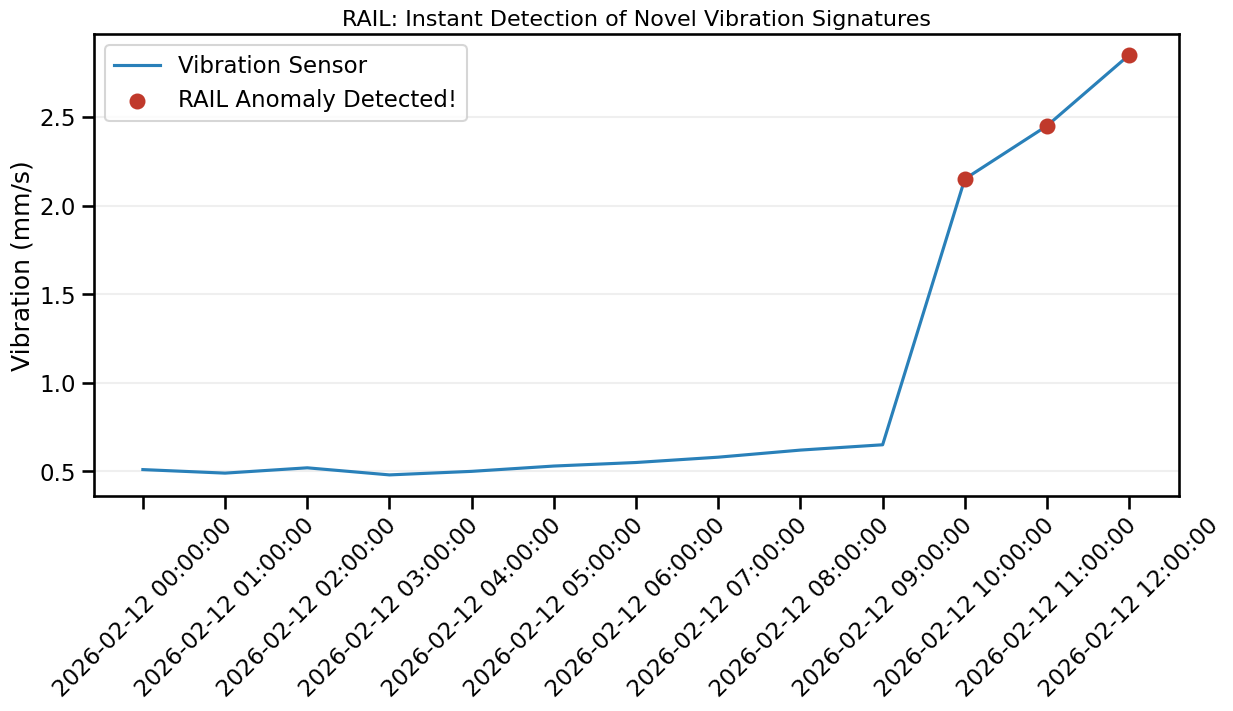

🟢 Success: RAIL identified the novel fault signature instantly, preventing equipment failure.


In [4]:
# RAIL Vibration Anomaly Logic
rt_df['vib_rolling_med'] = rt_df['vibration'].rolling(window=8).median()
rt_df['rail_anomaly'] = rt_df['vibration'] > (rt_df['vib_rolling_med'] * 1.5)

plt.figure(figsize=(14, 6))
plt.plot(rt_df['timestamp'], rt_df['vibration'], color='#2980b9', label='Vibration Sensor')
plt.scatter(rt_df[rt_df['rail_anomaly']]['timestamp'], rt_df[rt_df['rail_anomaly']]['vibration'], 
            color='#c0392b', s=100, label='RAIL Anomaly Detected!', zorder=5)

plt.title("RAIL: Instant Detection of Novel Vibration Signatures", fontsize=16)
plt.ylabel("Vibration (mm/s)")
plt.xticks(rotation=45)
plt.legend()
plt.grid(axis='y', alpha=0.2)
plt.show()

print("🟢 Success: RAIL identified the novel fault signature instantly, preventing equipment failure.")